# TF MoveNet: MULTIPOSE Estimation 

# 1. Importazione e installazione delle dipendenze

In [1]:
!pip install tensorflow tensorflow-hub opencv-python numpy psutil pandas openpyxl matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.1 MB/s  0:00:00m 5.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow-hub]


In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
from matplotlib import pyplot as plt 
import numpy as np
import psutil
import os 
import time
import glob
import pandas as pd
import platform 

In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")
print(f"CPU: {platform.processor()}")
print(f"RAM totale: {psutil.virtual_memory().total / 1e9:.1f} GB")

TensorFlow version: 2.21.0
GPU disponibili: []
CPU: arm
RAM totale: 8.6 GB


# 2. Importazione del modello 

In [3]:
model_path = './multipose_version'
model = hub.load(model_path)
movenet = model.signatures['serving_default']

# 3. Edges
- Stabiliamo i vari "spigoli" che caratterizzano lo scheletro della pose detection.
- Sono riportate nei testi ufficiali tutte le corrispondenze legate ad ognuno di essi.

In [4]:
EDGES = {
    (0, 1): 'm',
    (0, 2): 'c',
    (1, 3): 'm',
    (2, 4): 'c',
    (0, 5): 'm',
    (0, 6): 'c',
    (5, 7): 'm',
    (7, 9): 'm',
    (6, 8): 'c',
    (8, 10): 'c',
    (5, 6): 'y',
    (5, 11): 'm',
    (6, 12): 'c',
    (11, 12): 'y',
    (11, 13): 'm',
    (13, 15): 'm',
    (12, 14): 'c',
    (14, 16): 'c'
}

# 4.  Funzioni per la creazione dello scheletro
- `draw_connections`: sfrutta il dizionario EDGES e traccia le linee che definiscono lo scheletro
- `draw_keypoints`: accentua i punti salienti dello scheletro seguendo di pari passo i possibili movimenti delle connessioni. Nei documenti ufficiali sono listate le corrispondenze per ciascun keypoint. 

In [5]:
def draw_connections(frame, keypoints, edges, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))  

    for edge, color in edges.items(): 
        p1,p2 = edge
        y1, x1, c1 = shaped[p1]
        y2, x2, c2 = shaped[p2]
        if (c1 > confidence_threshold) & (c2 > confidence_threshold): 
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)       

In [6]:
def draw_keypoints(frame, keypoints, confidence_threshold): 
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))

    for kp in shaped: 
        ky, kx, kp_conf = kp
        if kp_conf > confidence_threshold: 
            cv2.circle(frame, (int(kx), int(ky)), 4, (0,255,0), -1)

# 5. Rendering dello scheletro su sfondo nero 
- Richiamando le funzioni `draw_connections` e `draw_keypoints` renderizziamo un secondo scheletro, copia del primo all'interno di uno sfondo nero dimensionalmente uguale al frame principale.
- La funzione `loop_through_people` permette al modello di riconoscere più soggetti, fino ad un limite di **6 sagome**.

In [7]:
def render_skeleton(frame, keypoints_with_scores, edges, confidence_threshold):
   

    black_screen = np.zeros(frame.shape, dtype=np.uint8)

    for person in keypoints_with_scores: 
        draw_connections(black_screen, person, edges, confidence_threshold)
    
        draw_keypoints(black_screen, person, confidence_threshold)
    
    return black_screen

In [8]:
def loop_through_people(frame, keypoints_with_scores, edges, confidence_threshold):
    for person in keypoints_with_scores: 
        draw_connections(frame, person, edges, confidence_threshold)
        draw_keypoints(frame, person, confidence_threshold)

##  6. Pre-processing
Convertiamo il frame grezzo nel tensore atteso dal modello:
- Copia del frame originale
- Resize proporzionale: larghezza fissa a 256px, altezza calcolata mantenendo le proporzioni e arrotondata al multiplo di 32 più vicino (requisito del modello)
- Cast a `int32` + `expand_dims` → shape `[1, target_height, 256, 3]`

In [9]:
#Resize dell'immagine
def pre_processing(frame, target_width, target_height):
     # Resize dell'immagine (proporzionale, multiplo di 32)
    img = cv2.resize(frame, (target_width, target_height))
    # Conversione di tipo (cast) + espansione delle dimensioni → forma [1, target_height, target_width, 3]
    input_img = tf.cast(tf.expand_dims(img, axis=0), dtype=tf.int32)
    return input_img

## 7. Inferenze
Passa il tensore al modello MoveNet Multipose e restituisce i keypoint per **fino a 6 persone**.
- Output grezzo: `[1, 6, 56]` → i primi 51 valori per persona sono i 17 keypoint × 3 `[y, x, conf]`
- Svolgiamo un reshape a `(6, 17, 3)` per iterare su ogni persona rilevata

In [10]:
def make_detections(movenet, input_img):
    results = movenet(input_img)
    # Reshape dell'output: (6 persone, 17 keypoint, 3 valori [y, x, conf])
    keypoints_with_scores = results['output_0'].numpy()[:,:,:51].reshape((6,17,3))
    return keypoints_with_scores

##  8. Post-processing
Calcola le metriche di qualità del rilevamento su tutte le persone rilevate:
- **`n_detected_people`**: quante delle 6 persone hanno almeno un keypoint sopra soglia
- **`conf_mean`**: confidenza media su tutti i keypoint di tutte le persone → proxy dell'accuratezza
- **`jitter`**: distanza media tra la posizione dei keypoint al frame `t` e al frame `t-1`, consentendo di misurare la stabilità del tracking

In [11]:
def post_processing(keypoints_with_scores, prev_keypoints_with_scores=None, confidence_threshold=0.3):
    # Numero di persone rilevate (almeno 1 keypoint sopra soglia)
    n_detected_people = int(
        sum(1 for person in keypoints_with_scores
            if (person[:, 2] > confidence_threshold).any())
    )

    # Confidenza media su tutti i keypoint di tutte le persone (proxy accuratezza)
    #filtrando solo le persone con almeno un keypoint sopra soglia
    detected = keypoints_with_scores[
    (keypoints_with_scores[:, :, 2] > confidence_threshold).any(axis=1)
    ]
    conf_mean = round(float(detected[:, :, 2].mean()), 4) if len(detected) > 0 else 0.0

    # Jitter: distanza media rispetto al frame precedente (proxy stabilità)
    if prev_keypoints_with_scores is not None:
        jitter = round(float(
            np.abs(keypoints_with_scores[:, :, :2] - prev_keypoints_with_scores[:, :, :2]).mean()
        ), 4)
    else:
        jitter = 0.0

    return {
        'n_detected_people': n_detected_people,
        'conf_mean':         conf_mean,
        'jitter':            jitter,
    }


## 9. Rendering finale
Combiniamo il frame principale con il frame con sfondo nero tramite la funzione `np.hstack`.

In [12]:
def rendering(frame, keypoints_with_scores, fps, cpu_usage, ram_usage, run, video_name):
    loop_through_people(frame, keypoints_with_scores, EDGES, 0.3)

    skeleton = render_skeleton(frame, keypoints_with_scores, EDGES, 0.3)


    combined_frames = np.hstack((frame, skeleton))

    cv2.putText(combined_frames, f"CPU: {cpu_usage}%",          (40, 150), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 7)
    cv2.putText(combined_frames, f"RAM: {ram_usage:.1f} MB",    (40, 270), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 7)
    cv2.putText(combined_frames, f"FPS: {int(fps)}",            (40, 390), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 7)
    cv2.putText(combined_frames, f"Video: {video_name[:15]}...", (40, 510), cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 255, 0), 7)
    cv2.putText(combined_frames, f"Run: {run+1}/2",             (40, 630), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 255), 7)

    return combined_frames


## 10. Raccolta metriche
Raccoglie tutte le metriche del frame in un dizionario. 
Ogni chiamata produce una riga dell'Excel finale.

In [13]:
def collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data):
    return {
        "Video name":       video_name,
        "Execution":        run + 1,
        "Frame N":          frame_count,
        "CPU (%)":          cpu_usage,
        "RAM (MB)":         round(ram_usage, 2),
        "FPS":              round(fps, 2),
        "Confidence":       post_data['conf_mean'],
        "People det":  post_data['n_detected_people'],
        "Jitter":           post_data['jitter'],
    }


# 11. Main (Fase di detection)

In [14]:
video_folder = "/Users/rebeccaspigacortes/Desktop/data_set_multipose/"
video_paths  = sorted(glob.glob(video_folder + "/*.mp4"))

process      = psutil.Process(os.getpid())
project_data = []


# Doppio ciclo
for video_path in video_paths:
    video_name = os.path.basename(video_path)
    print(f"\n{'='*40}")
    print(f"Processo: {video_name}")
    
    # Chiediamo direttamente al programma di analizzare la larghezza e l'altezza del video 
    cap_temp = cv2.VideoCapture(video_path)
    width = int(cap_temp.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap_temp.get(cv2.CAP_PROP_FRAME_HEIGHT)) 
    target_width  = 256
    proportion    = height / width
    target_height = int(round((target_width * proportion) / 32) * 32)
    cap_temp = cv2.VideoCapture(video_path)
    print(f"La dimensione del video è: {target_width}*{target_height}")

    for run in range(2):
        print(f"\nSto riproducendo: {video_name} | Esecuzione: {run + 1}/2")

        cap         = cv2.VideoCapture(video_path)
        frame_count = 0      # azzerato ad ogni run
        prev_time   = 0
        prev_keypoints_with_scores = None  # per il calcolo del jitter

        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame is None:
                break
            frame_count += 1

            # CPU e RAM 
            cpu_usage = psutil.cpu_percent()
            ram_usage = process.memory_info().rss / (1024 * 1024)

            # FPS
            curr_time = time.perf_counter()
            if prev_time != 0:
                frame_time = curr_time - prev_time
                fps = 1 / frame_time
            else:
                fps = 0
            prev_time = curr_time

            input_img             = pre_processing(frame, target_width, target_height)          # Stage 1
            keypoints_with_scores = make_detections(movenet, input_img)                         # Stage 2
            post_data             = post_processing(keypoints_with_scores,                      # Stage 3
                                                    prev_keypoints_with_scores)
            combined_frames       = rendering(frame, keypoints_with_scores,                     # Stage 4
                                              fps, cpu_usage, ram_usage, run, video_name)
            project_data.append(collect_metrics(video_name, run, frame_count,                  # Stage 5
                                                fps, cpu_usage, ram_usage, post_data))

            prev_keypoints_with_scores = keypoints_with_scores  # salva per il jitter al prossimo frame

            # print per vedere i risultati nella CONSOLE
            print(f"CPU: {cpu_usage}% | RAM: {ram_usage:.2f}MB | FPS: {fps:.1f}")
            cv2.imshow('Movenet Multipose and Skeleton Rendering', combined_frames)
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()


Processo: 01-volleyball.mp4
La dimensione del video è: 256*448

Sto riproducendo: 01-volleyball.mp4 | Esecuzione: 1/2
CPU: 14.9% | RAM: 846.39MB | FPS: 0.0
CPU: 32.6% | RAM: 950.55MB | FPS: 1.4
CPU: 60.2% | RAM: 952.81MB | FPS: 8.5
CPU: 54.4% | RAM: 948.77MB | FPS: 11.5
CPU: 67.2% | RAM: 920.39MB | FPS: 12.4
CPU: 87.8% | RAM: 883.61MB | FPS: 9.8
CPU: 58.1% | RAM: 864.95MB | FPS: 8.8
CPU: 54.1% | RAM: 863.83MB | FPS: 13.4
CPU: 60.0% | RAM: 849.64MB | FPS: 14.1
CPU: 80.6% | RAM: 829.94MB | FPS: 7.6
CPU: 0.0% | RAM: 821.20MB | FPS: 13.8
CPU: 0.0% | RAM: 817.81MB | FPS: 13.9
CPU: 0.0% | RAM: 820.25MB | FPS: 14.0
CPU: 0.0% | RAM: 826.64MB | FPS: 13.2
CPU: 0.0% | RAM: 828.81MB | FPS: 13.7
CPU: 0.0% | RAM: 823.95MB | FPS: 13.7
CPU: 0.0% | RAM: 826.91MB | FPS: 14.2
CPU: 0.0% | RAM: 818.33MB | FPS: 14.1
CPU: 45.8% | RAM: 819.09MB | FPS: 14.0
CPU: 43.6% | RAM: 824.42MB | FPS: 14.2
CPU: 40.0% | RAM: 824.44MB | FPS: 13.2
CPU: 40.0% | RAM: 824.47MB | FPS: 13.0
CPU: 0.0% | RAM: 824.59MB | FPS: 13.1

# 12. Export dati → Excel
Salva `project_data` in un file `.xlsx`.

In [15]:
df = pd.DataFrame(project_data)

excel_name = f"results_multipose_{platform.node()}.xlsx"
df.to_excel(excel_name, index=False)

print(f"Salvato: {excel_name}")
print(df.describe().round(3))

Salvato: results_multipose_MACBOOKAIR-2547.station.xlsx
       Execution    Frame N    CPU (%)   RAM (MB)        FPS  Confidence  \
count    15730.0  15730.000  15730.000  15730.000  15730.000   15730.000   
mean         1.5    207.766     17.681    555.396     12.440       0.390   
std          0.5    143.749     19.995     96.587      2.207       0.130   
min          1.0      1.000      0.000    295.670      0.000       0.000   
25%          1.0     94.000      0.000    487.890     10.680       0.303   
50%          1.5    188.000      0.000    527.520     12.520       0.385   
75%          2.0    282.000     36.500    635.060     14.020       0.467   
max          2.0    604.000    100.000    952.810     19.430       0.816   

       People det     Jitter  
count   15730.000  15730.000  
mean        3.624      0.124  
std         1.635      0.090  
min         0.000      0.000  
25%         2.000      0.051  
50%         4.000      0.117  
75%         5.000      0.185  
max        

# 13. Analisi stabilità tra i due run
Confronta le metriche medie del run 1 e del run 2.
Un modello stabile produce valori simili in entrambe le esecuzioni sullo stesso video.

In [16]:
summary = df.groupby("Execution")[["FPS", "CPU (%)", "RAM (MB)",
                                    "Confidence", "Jitter"]].mean().round(3)
print(summary)
print("\nDelta run1 vs run2:")
print((summary.loc[2] - summary.loc[1]).round(3))

              FPS  CPU (%)  RAM (MB)  Confidence  Jitter
Execution                                               
1          12.365   18.169   555.818        0.39   0.124
2          12.515   17.192   554.973        0.39   0.124

Delta run1 vs run2:
FPS           0.150
CPU (%)      -0.977
RAM (MB)     -0.845
Confidence    0.000
Jitter        0.000
dtype: float64


# 14. Cella di RIEPILOGO


In [17]:
print(f"{'='*40}")
print(f"RIEPILOGO ESECUZIONE")
print(f"{'='*40}")
print(f"Video processati:        {df['Video name'].nunique()}")
print(f"Frame totali analizzati: {len(df)}")
print(f"Esecuzioni per video:    {df['Execution'].max()}")
print(f"Frame totali (run x2):   {len(df)}")
print(f"\nVideo inclusi nel test:")
for v in sorted(df['Video name'].unique()):
    n_frames = len(df[df['Video name'] == v]) // int(df['Execution'].max())
    print(f"  - {v}  ({n_frames} frame/run)")

RIEPILOGO ESECUZIONE
Video processati:        21
Frame totali analizzati: 15730
Esecuzioni per video:    2
Frame totali (run x2):   15730

Video inclusi nel test:
  - 01-volleyball.mp4  (601 frame/run)
  - 02-beach-volley.mp4  (604 frame/run)
  - 03-running2.mp4  (302 frame/run)
  - 04-three-guys.mp4  (301 frame/run)
  - 05-yoga.mp4  (290 frame/run)
  - 06-partner-yoga.mp4  (278 frame/run)
  - 07-fit-guys.mp4  (574 frame/run)
  - 08-kpop-cover2.mp4  (572 frame/run)
  - 09-crowd-people.mp4  (300 frame/run)
  - 10-calisthenics.mp4  (600 frame/run)
  - 12-ciclist.mp4  (334 frame/run)
  - 13-basketballplay.mp4  (301 frame/run)
  - 14-dancing-ladies.mp4  (301 frame/run)
  - 15-equitation.mp4  (353 frame/run)
  - 16-kpop-cover.mp4  (301 frame/run)
  - 17-skill.mp4  (304 frame/run)
  - 18-roller.mp4  (302 frame/run)
  - 19-football-guy.mp4  (290 frame/run)
  - 20-gym-girl.mp4  (276 frame/run)
  - 20-multipose5.mp4  (322 frame/run)
  - 21-extra.mp4  (359 frame/run)


# 15. Grafici

Creiamo due grafici: 
- **metrics_mean_overview.png**
  > mostrerà la media per video di FPS, CPU, RAM, Confidence, People det e
    Jitter, attraverso un grafico a barre per ogni metrica. Sarà utile per
    confrontare le prestazioni del modello sui diversi video.

- **run_comparison.png**
  > confronterà i valori medi del Run 1 e Run 2 per ogni metrica, in un              grafico a barre. Sarà utile per verificare la stabilità del modello tra le       due esecuzioni 

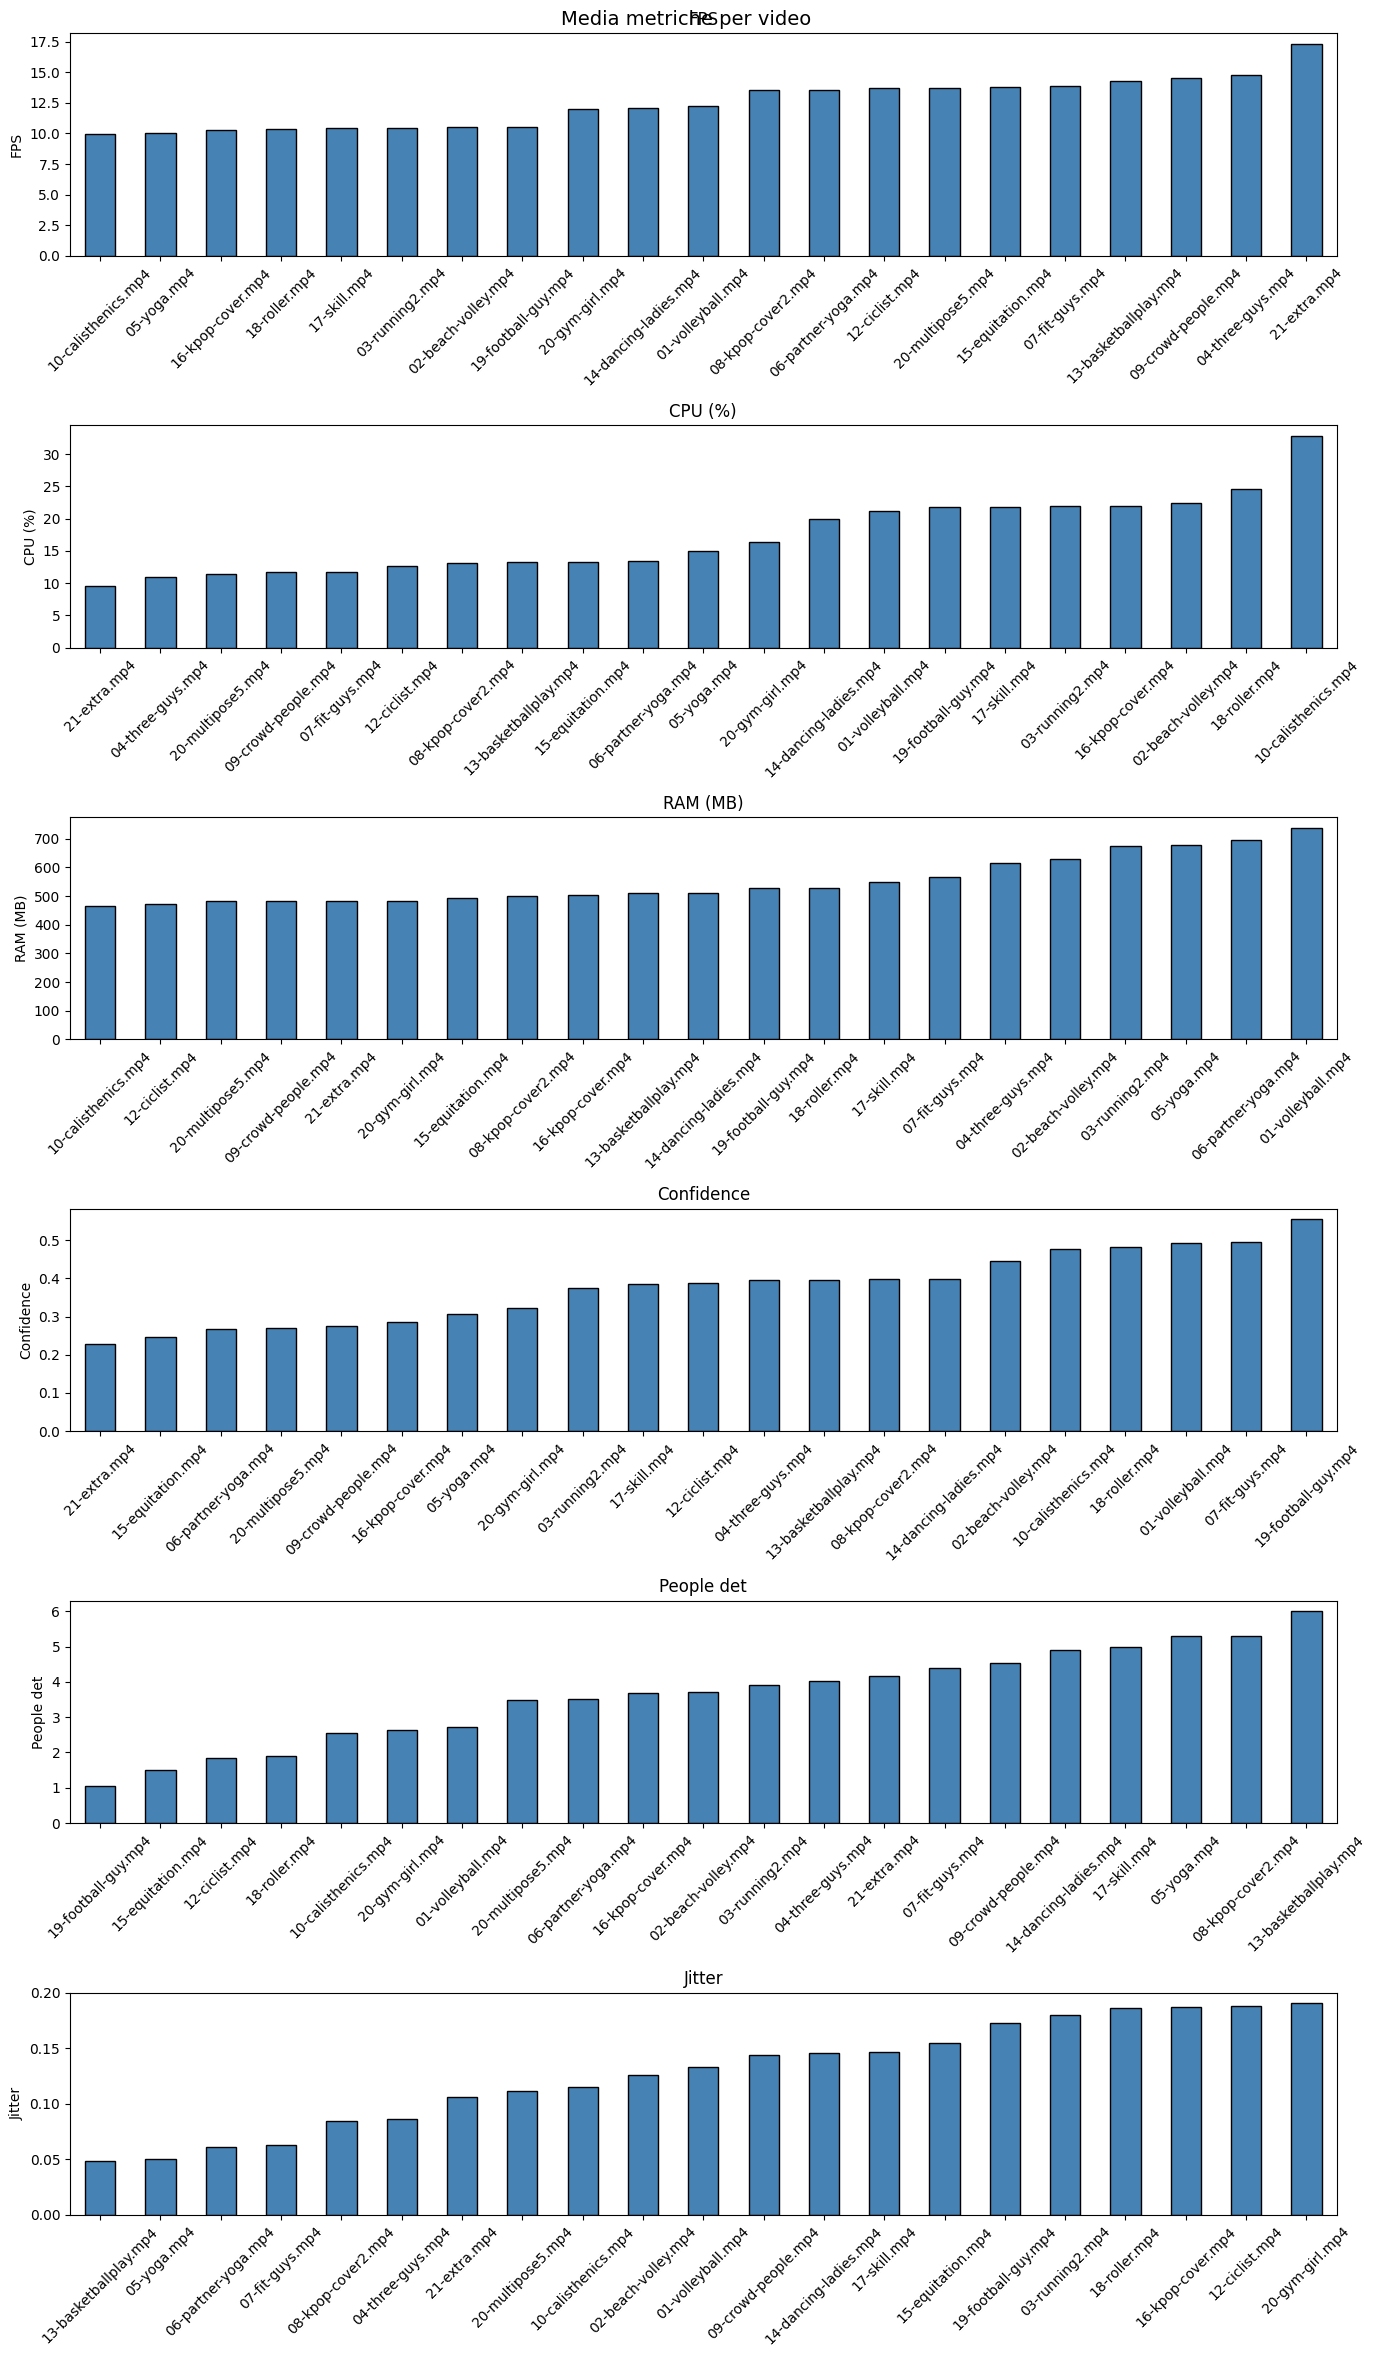

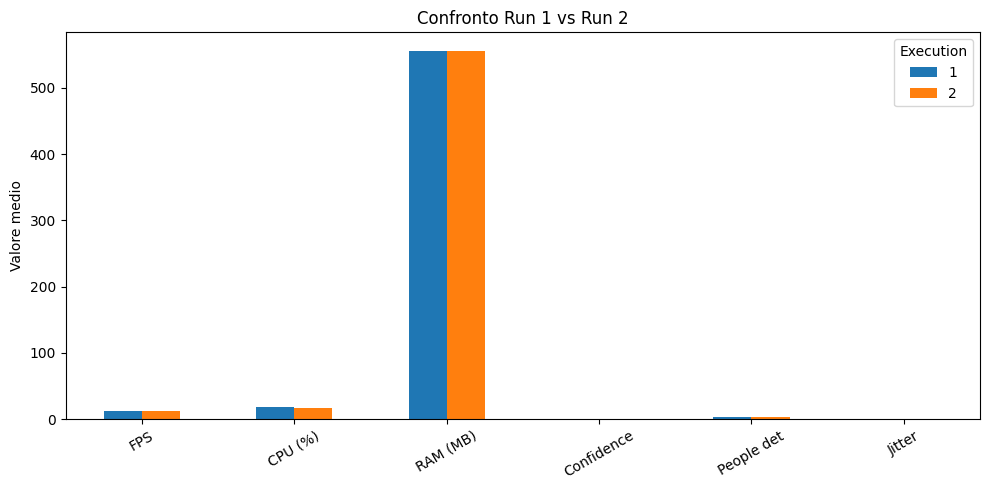

In [18]:
metrics = ['FPS', 'CPU (%)', 'RAM (MB)', 'Confidence', 'People det', 'Jitter']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))
fig.suptitle("Media metriche per video", fontsize=14)

for ax, metric in zip(axes, metrics):
    means = df.groupby('Video name')[metric].mean().sort_values()
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("metrics_mean_overview.png", dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: confronto Run 1 vs Run 2
summary = df.groupby("Execution")[metrics].mean().round(3)

summary.T.plot(kind="bar", figsize=(10, 5), title="Confronto Run 1 vs Run 2")
plt.ylabel("Valore medio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()